<a href="https://colab.research.google.com/github/samizard2016/data_analytics/blob/main/data_analytics_arrays_and_heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# any, all
arr1 = np.random.randint(10, size=10)
arr2 = np.random.randint(10, size=10)

print("First Array:", arr1)
print("\nSecond Array:", arr2)

print("All values of Array's are equal: ", np.all(arr1 == arr2))
print("If at least one value of both Array's is equal: ", np.any(arr1 == arr2))



First Array: [4 5 3 6 8 8 2 9 4 9]

Second Array: [5 8 4 8 3 8 9 3 9 8]
All values of Array's are equal:  False
If at least one value of both Array's is equal:  True


In [ ]:
# argsort and argmax
# Sort the array and return the indices
arr = np.random.randint(10, size=40)
indices = np.argsort(arr)

# Print original and sorted array
print("Orignial Array:\n",arr)
print("\nSorted Array : \n", arr[indices])


# Find the index of maximum item
max_index = np.argmax(arr)

# Print original and sorted array
print("Original Array:\n",arr)
print(f"\nMaximum Element of an Array is {arr[max_index]} and the index is {max_index}")



Orignial Array:
 [5 0 1 1 9 3 6 6 5 5 5 4 8 0 7 6 7 2 5 3 6 9 6 0 8 9 8 6 3 2 3 9 5 8 0 5 2
 3 7 5]

Sorted Array : 
 [0 0 0 0 1 1 2 2 2 3 3 3 3 3 4 5 5 5 5 5 5 5 5 6 6 6 6 6 6 7 7 7 8 8 8 8 9
 9 9 9]
Original Array:
 [5 0 1 1 9 3 6 6 5 5 5 4 8 0 7 6 7 2 5 3 6 9 6 0 8 9 8 6 3 2 3 9 5 8 0 5 2
 3 7 5]

Maximum Element of an Array is 9 and the index is 4


In [ ]:
# Create a random array
arr = np.random.randint(1, 100, size=30)

# Clip the array between range a range - this would never come from
# something like randint(1,100) and we need to convert every single
# elements remain within the interval - lower values clipped to min and higher
# values clipped to max. This is helpful in treating outliers and stabilizing
# neural network training
n_min = 70
n_max = 85
clipped_arr = np.clip(arr, n_min,n_max)

# Print original and clipped array
print(f"Original Array of size {len(arr)}: {arr}\n")
print(f"Clipped Array between {n_min} and {n_max} and size {len(clipped_arr)}: {clipped_arr}")


Original Array of size 30: [84  7  4 83 93 23 53 39 11 60 24 41 83  5 38 80 34 67 24 89 39 92 97 66
 26 19 40  7 48 50]

Clipped Array between 70 and 85 and size 30: [84 70 70 83 85 70 70 70 70 70 70 70 83 70 70 80 70 70 70 85 70 85 85 70
 70 70 70 70 70 70]


In [ ]:
# Load iris dataset
iris = sns.load_dataset("iris")
# check the mean length of sepal by species
iris.groupby('species').mean()['sepal_length']



,sepal_length
species,
setosa,5.006
versicolor,5.936
virginica,6.588


In [47]:
minw = iris['sepal_width'].value_counts().index.min()
maxw = iris['sepal_width'].value_counts().index.max()
print(f"min width {minw} and max width {maxw}")
iris["sepal_width_category"] = pd.qcut(iris["sepal_width"], q=3,labels=['small','medium','large'])
iris["sepal_width_category"].value_counts()
pt = pd.pivot_table(iris,values='sepal_length', index=['sepal_width_category'],
               columns=['species'], aggfunc='mean').reset_index()
# pt.columns.name = None
pt.index.name = None
print(pt)

min width 2.0 and max width 4.4
species sepal_width_category    setosa  versicolor  virginica
0                      small  4.450000    5.802941   6.338095
1                     medium  4.720000    6.228571   6.728571
2                      large  5.169697    6.150000   6.875000


/tmp/ipykernel_188/4213816198.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt = pd.pivot_table(iris,values='sepal_length', index=['sepal_width_category'],


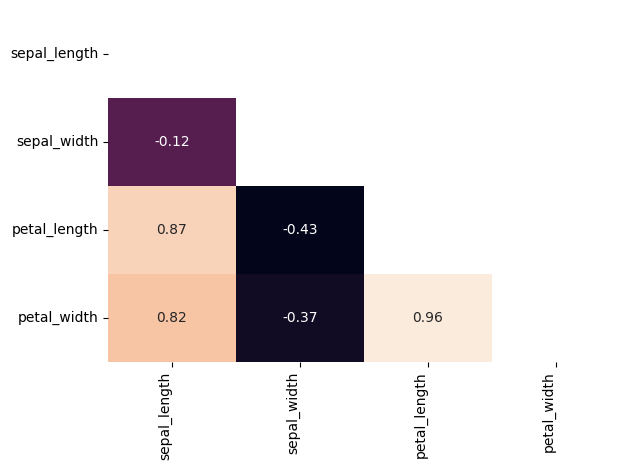

In [ ]:
# Load iris dataset
iris = sns.load_dataset("iris")


# Find correlation between iris features leaving the last column of
# the flower type
corr_matrix = iris.iloc[:, :-1].corr()

# Create mask using triu
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create heatmap
ax = sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cbar=False);
# Rotate labels using set_xticklabels
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout() # Ensures labels fit

